In [1]:
import numpy as np
import math
from scipy.integrate import quad
from scipy.special import gamma as Gamma, exp1  # E1(x)
import astropy.units as u

# -------------------------
# constants
# -------------------------
c_kms = 299792.458  # km/s

# -------------------------
# Koopmans (2005) f^{-1} — vectorized
# -------------------------
def f_inv_vec(gamma3d, delta, beta):
    """
    Vectorized 1/f(gamma, delta, beta) of Koopmans (2005).
    Accepts scalars or arrays; returns array broadcast to common shape.
    """
    g  = np.asarray(gamma3d, dtype=float)
    d  = np.asarray(delta,    dtype=float)
    b  = np.asarray(beta,     dtype=float)
    # broadcast
    g, d, b = np.broadcast_arrays(g, d, b)

    xi   = g + d - 2.0
    pref = 1.0 / (2.0 * np.sqrt(np.pi))
    term1 = (xi - 3.0) * (xi - 2.0*b) / (d - 3.0)

    num = Gamma(xi/2.0) * Gamma((xi+2.0)/2.0)
    den = Gamma((xi+2.0)/2.0) * Gamma((xi-1.0)/2.0) - b * Gamma(xi/2.0) * Gamma((xi+1.0)/2.0)
    term2 = num / den

    term3 = Gamma((d-1.0)/2.0) * Gamma((g-1.0)/2.0) / (Gamma(d/2.0) * Gamma(g/2.0))

    out = pref * term1 * term2 * term3

    # domain masks: avoid singularities and non-finite results
    bad = (np.isclose(d, 3.0) |
           np.isclose(xi, 3.0) |
           np.isclose(xi, 2.0*b) |
           ~np.isfinite(out))
    return np.where(bad, np.nan, out)

# -------------------------
# w_phi distances
# w_phi(z) = -1 + (1+w0) exp(-alpha z)
# F(z) = exp{ 3 e^{alpha} (1+w0) [E1(alpha) - E1(alpha(1+z))] }
# H(z)^2/H0^2 = Om(1+z)^3 + Ok(1+z)^2 + (1-Om-Ok) F(z)
# -------------------------
def _da_wphi_scalar(z1, z2, w0, alpha, Ok, H0, Om, c=c_kms):
    """Scalar D_A(z1->z2) [Mpc] for the w_phi model (used internally)."""
    if np.isclose(z1, z2) or (z2 < z1):
        return 0.0

    Ode = 1.0 - Om - Ok
    A = 3.0 * np.exp(alpha) * (1.0 + w0)
    E1_alpha = exp1(alpha)

    def F_of_z(z):
        return np.exp(A * (E1_alpha - exp1(alpha * (1.0 + z))))

    def Ez_inv(z):
        Ez2 = Om*(1.0+z)**3 + Ok*(1.0+z)**2 + Ode*F_of_z(z)
        return 1.0/np.sqrt(Ez2)

    def sinn(ok, x):
        if ok < 0.0:
            k = np.sqrt(-ok);  return np.sin(k*x)/k
        if ok > 0.0:
            k = np.sqrt(ok);   return np.sinh(k*x)/k
        return x

    chi, _ = quad(Ez_inv, z1, z2, epsabs=0, epsrel=1e-8, limit=200)
    return (c / H0) * sinn(Ok, chi) / (1.0 + z2)

def da_wphi_vec(z1, z2, w0, alpha, Ok, H0, Om, c=c_kms):
    """
    Vectorized angular-diameter distance D_A(z1->z2) [Mpc] for w_phi cosmology.
    All inputs can be scalars or arrays; output broadcasts to common shape.
    """
    z1 = np.asarray(z1, dtype=float)
    z2 = np.asarray(z2, dtype=float)
    w0 = float(w0); alpha = float(alpha); Ok = float(Ok); H0 = float(H0); Om = float(Om); c = float(c)

    # broadcast z1 and z2 onto a common shape
    z1b, z2b = np.broadcast_arrays(z1, z2)
    out = np.empty_like(z1b, dtype=float)

    # flatten, compute per-pair, then reshape
    it = np.nditer([z1b, z2b, out], op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zi, zj, o in it:
        o[...] = _da_wphi_scalar(float(zi), float(zj), w0, alpha, Ok, H0, Om, c)
    return out

# -------------------------
# σ_los for spherical EPL (vectorized, w_phi cosmology)
# -------------------------
def sigma_EPL_wphi_vec(zl, zs, theta_E_arcsec, theta_ap_arcsec,
                       gamma3d, delta, beta,
                       w0, alpha, Ok, H0, Om, c=c_kms):
    """
    Luminosity-weighted LOS dispersion within circular aperture for spherical power-law mass,
    using w_phi cosmology distances. Accepts scalars or arrays; all inputs broadcast.
    """
    zl = np.asarray(zl, dtype=float)
    zs = np.asarray(zs, dtype=float)
    thE = np.asarray(theta_E_arcsec, dtype=float) * u.arcsec.to('rad')
    thA = np.asarray(theta_ap_arcsec, dtype=float) * u.arcsec.to('rad')

    # Broadcast all lens/source dependent arrays to a common shape
    zl, zs, thE, thA, gamma3d, delta, beta = np.broadcast_arrays(zl, zs, thE, thA, gamma3d, delta, beta)

    # Distances [Mpc]
    Ds  = da_wphi_vec(0.0, zs, w0, alpha, Ok, H0, Om, c)
    Dl  = da_wphi_vec(0.0, zl, w0, alpha, Ok, H0, Om, c)
    Dls = da_wphi_vec(zl,  zs, w0, alpha, Ok, H0, Om, c)

    # f^{-1}(γ,δ,β)
    fi = f_inv_vec(gamma3d, delta, beta)

    # Prefactor and final σ (km/s). All terms already broadcast.
    fac = (c**2) / (4.0 * np.pi) * (Ds / Dls) * thE**(gamma3d - 1.0) * thA**(2.0 - gamma3d)
    sigma = np.sqrt(fac / fi)

    # If zs <= zl, D_A(zl->zs)=0 → fac→∞；我们返回 NaN 以显式标记无效对
    bad_pair = (zs <= zl) | ~np.isfinite(Dls) | (Dls <= 0)
    return np.where(bad_pair, np.nan, sigma)


In [2]:

from dataclasses import dataclass
from typing import Optional, Literal
from astropy import units as u
from astropy import constants as const
import numpy as np
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

C_KMS = const.c.to(u.km/u.s).value

ModelT = Literal['constw', 'cpl', 'wphi']

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (通常可忽略)
    # ---- choose dark-energy model via `model` ----
    model: ModelT = 'cpl'       # 'constw' | 'cpl' | 'wphi'
    # const-w:
    w: Optional[float] = None
    # CPL: w(a)=w0+wa(1-a)
    w0: float = -1.0
    wa: float = 0.0
    # w_phi: w(z) = -1 + (1+w0) exp(-alpha z)
    alpha: Optional[float] = None

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """
    ρ_DE(z)/ρ_DE(0) for the chosen dark-energy model.
    - constw: (1+z)^{3(1+w)}
    - cpl:    (1+z)^{3(1+w0+wa)} * exp[-3 wa z/(1+z)]
    - wphi:   F(z) per your definition using exp1 (E1).
              F(z) = exp{ 3 e^{alpha} (1+w0) [E1(alpha) - E1(alpha(1+z))] }
    """
    m = cp.model
    if m == 'constw':
        w = cp.w if cp.w is not None else -1.0
        return (1.0 + z)**(3.0 * (1.0 + w))

    if m == 'cpl':
        return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

    if m == 'wphi':
        if cp.alpha is None:
            raise ValueError("For model='wphi', please set CosmoParams.alpha (and w0).")
        A = 3.0 * np.exp(cp.alpha) * (1.0 + cp.w0)
        return np.exp(A * (exp1(cp.alpha) - exp1(cp.alpha * (1.0 + z))))

    raise ValueError(f"Unknown DE model: {m}")

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0 with chosen dark-energy model."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0*(1.0+z)**3 + cp.Or0*(1.0+z)**4 + cp.Ok0*(1.0+z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)，x = √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12: return x
    return np.sinh(x) if Ok0 > 0.0 else np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp); chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- wrappers (unchanged signatures + new args: model, alpha) ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) Galaxy–galaxy lens: R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None,
                               w0: float = -1.0, wa: float = 0.0,
                               model: ModelT = 'cpl', alpha: Optional[float] = None) -> float:
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) Time-delay: D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None,
                        w0: float = -1.0, wa: float = 0.0,
                        model: ModelT = 'cpl', alpha: Optional[float] = None) -> float:
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) DSP: β = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None,
                       w0: float = -1.0, wa: float = 0.0,
                       model: ModelT = 'cpl', alpha: Optional[float] = None) -> float:
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

# -------- vectorized shells: add (model, alpha) pass-through --------
def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0,
    model: ModelT = 'cpl', alpha: Optional[float] = None
):
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = float(zl_i), float(zs_i)
        o[...] = np.nan if zs_f <= zl_f else Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0,
    model: ModelT = 'cpl', alpha: Optional[float] = None
):
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = float(zl_i), float(zs_i)
        o[...] = np.nan if zs_f <= zl_f else (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0,
    model: ModelT = 'cpl', alpha: Optional[float] = None
):
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r,
                     model=model, w=w, w0=w0, wa=wa, alpha=alpha)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = float(zl_i), float(z1_i), float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from typing import Dict

# ====== 标量观测量封装（复用你已有的主函数，记得 model='wphi'） ======
def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

def Ddt_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return time_delay_distance(float(zl), float(zs), **cosmo)

def beta_scalar(zl: float, zs1: float, zs2: float, cosmo: Dict) -> float:
    return double_source_beta(float(zl), float(zs1), float(zs2), **cosmo)

# ====== 数值导数：支持 p in {'w0','alpha'}，模型固定为 wphi ======
def _prepare_cosmo_wphi(cosmo_in: Dict) -> Dict:
    cosmo = dict(cosmo_in)  # shallow copy
    cosmo['model'] = 'wphi'
    # 强制存在 alpha 与 w0（若缺失给默认）
    cosmo.setdefault('w0', -1.0)
    cosmo.setdefault('alpha', 1.0)
    return cosmo

def _finite_diff_step(p: str, val: float, eps_rel=1e-5, eps_abs=1e-5):
    """
    为 wphi 的参数选择步长:
      - w0 可能在 -1 附近，采用绝对步长（eps_abs）更稳健；
      - alpha>0，采用 max(eps_abs, val*eps_rel)，并夹到 [alpha_min, ...]。
    返回 (p_minus, p_plus)。
    """
    if p == 'w0':
        dp = eps_abs
        return val - dp, val + dp
    elif p == 'alpha':
        # 强制 alpha > 0，避免 E1 的分支问题
        alpha_min = 1e-6
        base = max(val, alpha_min)
        dp = max(eps_abs, base * eps_rel)
        return max(alpha_min, base - dp), base + dp
    else:
        raise ValueError("Only 'w0' and 'alpha' are supported in wphi sensitivity.")

def dlnObs_dp_wphi(obs_fn, zl, zs_or_tuple, cosmo_in: Dict, p: str,
                   eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    """
    通用导数器：obs_fn ∈ {R_scalar, Ddt_scalar, beta_scalar}
    - 若 obs 是 beta，zs_or_tuple = (zs1, zs2)；否则为 zs (float)。
    """
    cosmo = _prepare_cosmo_wphi(cosmo_in)
    # 基值
    if obs_fn is beta_scalar:
        zl_f = float(zl)
        zs1_f, zs2_f = float(zs_or_tuple[0]), float(zs_or_tuple[1])
        base = obs_fn(zl_f, zs1_f, zs2_f, cosmo)
    else:
        zl_f = float(zl)
        zs_f = float(zs_or_tuple)
        base = obs_fn(zl_f, zs_f, cosmo)

    if not np.isfinite(base) or base <= 0:
        return np.nan

    # 步长
    val = float(cosmo.get(p, 0.0))
    p_minus, p_plus = _finite_diff_step(p, val, eps_rel=eps_rel, eps_abs=eps_abs)

    cosmo_m = dict(cosmo); cosmo_m[p] = p_minus
    cosmo_p = dict(cosmo); cosmo_p[p] = p_plus

    if obs_fn is beta_scalar:
        bm = obs_fn(zl_f, zs1_f, zs2_f, cosmo_m)
        bp = obs_fn(zl_f, zs1_f, zs2_f, cosmo_p)
    else:
        bm = obs_fn(zl_f, zs_f, cosmo_m)
        bp = obs_fn(zl_f, zs_f, cosmo_p)

    if (bm <= 0) or (bp <= 0) or (not np.isfinite(bm)) or (not np.isfinite(bp)):
        return np.nan

    return float((np.log(bp) - np.log(bm)) / (p_plus - p_minus))

# 便捷别名
def dlnR_dp_wphi(zl, zs, cosmo, p, **kw):    return dlnObs_dp_wphi(R_scalar,   zl, zs,       cosmo, p, **kw)
def dlnDdt_dp_wphi(zl, zs, cosmo, p, **kw):  return dlnObs_dp_wphi(Ddt_scalar, zl, zs,       cosmo, p, **kw)
def dlnbeta_dp_wphi(zl, zs1, zs2, cosmo, p, **kw): return dlnObs_dp_wphi(beta_scalar, zl, (zs1, zs2), cosmo, p, **kw)

# ====== 3×2 绘图：三行 (R, D_dt, beta) × 两列 (w0, alpha) ======
def plot_sensitivity_wphi_3x2(
    cosmo_base: Dict,
    *,
    zl_min=0.0, zl_max=2.0, zl_step=0.05,
    zs_min=0.05, zs_max=3.0, zs_step=0.05,
    zs2_fixed=2.0, zs1_step=0.05, eps=1e-6,
    sigma_frac=0.1,     # 归一化（可理解为观测对数不确定度）
    cmap="viridis",
    figsize=(12, 10),
    outputname="wphi_sensitivity_3x2.png"
):
    """
    3 rows × 2 columns:
        Row 1:  |∂ ln R / ∂ p| / σ
        Row 2:  |∂ ln D_dt / ∂ p| / σ
        Row 3:  |∂ ln β_DSP / ∂ p| / σ
        Cols:   p ∈ {w0, alpha}
    其中：
      - R 使用 (zl, zs) 网格；
      - D_dt 使用同一 (zl, zs)；
      - β_DSP 使用 (zl, zs1) 网格（固定 z_s2 = zs2_fixed）。
    """
    # —— 准备 wphi 宇宙学字典（确保带 model、w0、alpha） ——
    cosmo = _prepare_cosmo_wphi(cosmo_base)

    # —— 网格 —— 
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, min(zs2_fixed - 1e-6, zs_max) + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # —— 颜色刻度（对数）——
    vmin, vmax = 1e-4, 1e1
    levels01 = np.logspace(-4, 0, 16)
    levels02 = np.linspace(1, 10, 10)[1:]
    levels = np.r_[levels01, levels02]
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    # —— 画布 —— 
    fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=False, sharey=False)
    axes = np.asarray(axes)
    fig.subplots_adjust(right=0.86)  # 右侧预留颜色条

    params = ['w0', 'alpha']
    panel_labels = {
        ('R', 'w0'):     r"$\partial \ln \mathcal{R}_{DR}/\partial w_0$",
        ('R', 'alpha'):  r"$\partial \ln \mathcal{R}_{DR}/\partial \alpha$",
        ('Ddt','w0'):    r"$\partial \ln \mathcal{R}_{\Delta t}/\partial w_0$",
        ('Ddt','alpha'): r"$\partial \ln \mathcal{R}_{\Delta t}/\partial \alpha$",
        ('beta','w0'):   r"$\partial \ln \mathcal{R}_{DSPDR}/\partial w_0$",
        ('beta','alpha'):r"$\partial \ln \mathcal{R}_{DSPDR}/\partial \alpha$",
    }
    txt_kw = dict(ha="right", va="bottom", fontsize=16)

    # —— helper：在 (zl,zs) 网格上评估 R 或 D_dt 的敏感度 —— 
    def _grid_S_zlzs(deriv_fn, p):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):      # zs index
            for j in range(ZL.shape[1]):  # zl index
                zl, zs = ZL[i, j], ZS[i, j]
                if not (zs > zl > 0.0):
                    continue
                d = deriv_fn(zl, zs, cosmo, p)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # —— helper：在 (zl,zs1) 网格上评估 β 的敏感度（z_s2 固定） —— 
    def _grid_S_beta(p):
        S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
        for i in range(ZL_b.shape[0]):     # zs1 index
            for j in range(ZL_b.shape[1]): # zl index
                zl, zs1 = ZL_b[i, j], ZS1[i, j]
                if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                    continue
                d = dlnbeta_dp_wphi(zl, zs1, zs2_fixed, cosmo, p)
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # -------- Row 1: R (w0, alpha) --------
    for col, p in enumerate(params):
        ax = axes[0, col]
        S = _grid_S_zlzs(dlnR_dp_wphi, p)
        cf = ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        if col == 0:
            ax.set_ylabel(r"$z_s$", fontsize=13)
        ax.set_xlabel(r"$z_l$", fontsize=13)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, panel_labels[('R', p)], transform=ax.transAxes, **txt_kw)

    # -------- Row 2: D_dt (w0, alpha) --------
    for col, p in enumerate(params):
        ax = axes[1, col]
        S = _grid_S_zlzs(dlnDdt_dp_wphi, p)
        cf = ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
        if col == 0:
            ax.set_ylabel(r"$z_s$", fontsize=13)
        ax.set_xlabel(r"$z_l$", fontsize=13)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, panel_labels[('Ddt', p)], transform=ax.transAxes, **txt_kw)

    # -------- Row 3: beta_DSP (w0, alpha) --------
    for col, p in enumerate(params):
        ax = axes[2, col]
        S = _grid_S_beta(p)
        cf = ax.contourf(zl_grid, zs1_grid, S, levels=levels, norm=norm, cmap=cmap)
        if col == 0:
            ax.set_ylabel(fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.2f}$)", fontsize=13)
        ax.set_xlabel(r"$z_l$", fontsize=13)
        ax.grid(alpha=0.2)
        ax.text(0.98, 0.02, panel_labels[('beta', p)], transform=ax.transAxes, **txt_kw)

    # ---- shared colorbar ----
    cax = fig.add_axes([0.88, 0.15, 0.02, 0.70])
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )
    cb.set_label(r"Sensitivity  $|\partial \ln \mathcal{R}| / \sigma_{\ln \mathcal{R}}$", fontsize=12)

    plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_2372864/4030246815.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])


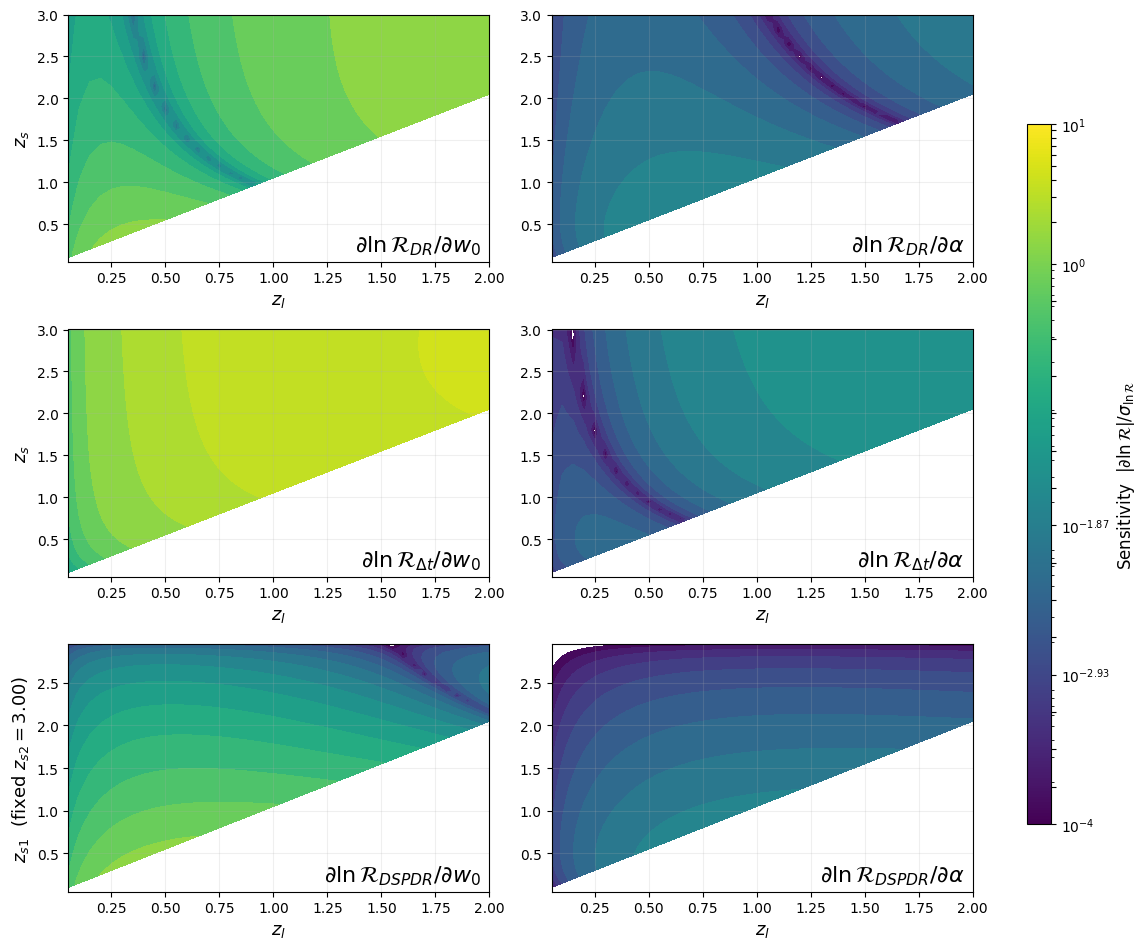

In [12]:
cosmo_wphi = dict(
    H0=70.0, omega_m=0.3, omega_k=0.0,
    w0=-0.95, alpha=1.45,
    model='wphi',
)

plot_sensitivity_wphi_3x2(
    cosmo_wphi,
    zl_min=0.05, zl_max=2.0, zl_step=0.05,
    zs_min=0.05,  zs_max=3.0,  zs_step=0.05,
    zs2_fixed=3.0, zs1_step=0.05,
    sigma_frac=0.05,
    outputname="wphi_sensitivity_3x2.png"
)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from typing import Dict

def plot_sensitivity_wphi_alpha_3x1(
    cosmo_base: Dict,
    *,
    zl_min=0.0, zl_max=2.0, zl_step=0.05,
    zs_min=0.05, zs_max=3.0, zs_step=0.05,
    zs2_fixed=2.0, zs1_step=0.05, eps=1e-6,
    sigma_frac=0.1,
    cmap="viridis",
    figsize=(6.5, 10),
    outputname="wphi_sensitivity_alpha_3x1.png"
):
    """
    3 rows × 1 column (alpha only):
        Row 1: |∂ ln R / ∂ alpha| / σ
        Row 2: |∂ ln D_dt / ∂ alpha| / σ
        Row 3: |∂ ln β_DSP / ∂ alpha| / σ  (with fixed z_s2)
    """
    # --- ensure wphi dict ---
    cosmo = dict(cosmo_base)
    cosmo['model'] = 'wphi'
    cosmo.setdefault('w0', -1.0)
    cosmo.setdefault('alpha', 1.0)

    # --- grids ---
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, min(zs2_fixed - 1e-6, zs_max) + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # --- log color scale ---
    vmin, vmax = 1e-4, 1e1
    levels01 = np.logspace(-4, 0, 16)
    levels02 = np.linspace(1, 10, 10)[1:]
    levels = np.r_[levels01, levels02]
    norm   = LogNorm(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=False, sharey=False)
    axes = np.asarray(axes)
    fig.subplots_adjust(right=0.86)  # room for shared colorbar

    txt_kw = dict(ha="right", va="bottom", fontsize=14)

    # helpers
    def _grid_S_zlzs(deriv_fn):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):
            for j in range(ZL.shape[1]):
                zl, zs = ZL[i, j], ZS[i, j]
                if not (zs > zl > 0.0):
                    continue
                d = deriv_fn(zl, zs, cosmo, 'alpha')
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    def _grid_S_beta():
        S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
        for i in range(ZL_b.shape[0]):
            for j in range(ZL_b.shape[1]):
                zl, zs1 = ZL_b[i, j], ZS1[i, j]
                if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                    continue
                d = dlnbeta_dp_wphi(zl, zs1, zs2_fixed, cosmo, 'alpha')
                S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
        return np.ma.masked_invalid(S)

    # Row 1: R vs (zl, zs)
    ax = axes[0]
    S = _grid_S_zlzs(dlnR_dp_wphi)
    ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
    ax.set_ylabel(r"$z_s$")
    ax.set_xlabel(r"$z_l$")
    ax.grid(alpha=0.2)
    ax.text(0.98, 0.02, r"$\partial \ln \mathcal{R}_{DR}/\partial \alpha$", transform=ax.transAxes, **txt_kw)

    # Row 2: D_dt vs (zl, zs)
    ax = axes[1]
    S = _grid_S_zlzs(dlnDdt_dp_wphi)
    ax.contourf(zl_grid, zs_grid, S, levels=levels, norm=norm, cmap=cmap)
    ax.set_ylabel(r"$z_s$")
    ax.set_xlabel(r"$z_l$")
    ax.grid(alpha=0.2)
    ax.text(0.98, 0.02, r"$\partial \ln \mathcal{R}_{\Delta t}/\partial \alpha$", transform=ax.transAxes, **txt_kw)

    # Row 3: beta vs (zl, zs1) with fixed zs2
    ax = axes[2]
    S = _grid_S_beta()
    ax.contourf(zl_grid, zs1_grid, S, levels=levels, norm=norm, cmap=cmap)
    ax.set_ylabel(fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.2f}$)")
    ax.set_xlabel(r"$z_l$")
    ax.grid(alpha=0.2)
    ax.text(0.98, 0.02, r"$\partial \ln \mathcal{R}_{DSPDR}/\partial \alpha$", transform=ax.transAxes, **txt_kw)

    # shared colorbar
    cax = fig.add_axes([0.88, 0.15, 0.02, 0.70])
    cb = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )
    cb.set_label(r"Sensitivity  $|\partial \ln \mathcal{R}| / \sigma_{\ln \mathcal{R}}$", fontsize=12)

    plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_2372864/1793312817.py:118: RuntimeWarning: divide by zero encountered in scalar divide
  return Ds(zs, cp) / Dls(zl, zs, cp)
/tmp/ipykernel_2372864/1793312817.py:131: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)
/tmp/ipykernel_2372864/2441371711.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])


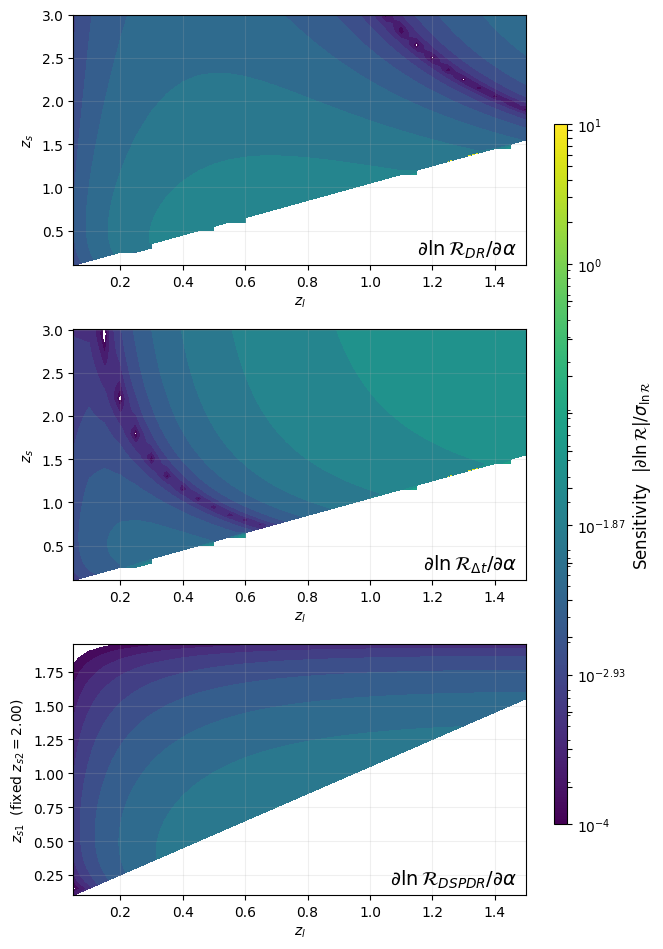

In [11]:
cosmo_wphi = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-0.95, alpha=1.45, model='wphi')
plot_sensitivity_wphi_alpha_3x1(
    cosmo_wphi,
    zl_min=0.05, zl_max=1.5, zl_step=0.05,
    zs_min=0.10, zs_max=3.0, zs_step=0.05,
    zs2_fixed=2.0, zs1_step=0.05,
    sigma_frac=0.05,
    outputname="wphi_sensitivity_alpha_3x1.png"
)


# slider

In [13]:
# =========================
# General 3×1 sensitivity tool + notebook widget
# =========================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from typing import Dict, Tuple

# --- observable scalars (rely on your existing implementations) ---
def R_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return galaxy_lens_distance_ratio(float(zl), float(zs), **cosmo)

def Ddt_scalar(zl: float, zs: float, cosmo: Dict) -> float:
    return time_delay_distance(float(zl), float(zs), **cosmo)

def beta_scalar(zl: float, zs1: float, zs2: float, cosmo: Dict) -> float:
    return double_source_beta(float(zl), float(zs1), float(zs2), **cosmo)

# --- prepare cosmology dict for a chosen model ---
def _prepare_cosmo(model: str, H0: float, Om0: float, Ok0: float,
                   w: float = None, w0: float = None, wa: float = None, alpha: float = None) -> Dict:
    c = dict(H0=H0, omega_m=Om0, omega_k=Ok0, model=model)
    if model == 'constw':
        c['w'] = float(w)
    elif model == 'cpl':
        c['w0'] = float(w0)
        c['wa'] = float(wa)
    elif model == 'wphi':
        c['w0']   = float(w0)
        c['alpha'] = float(alpha)
    else:
        raise ValueError("model must be one of {'constw','cpl','wphi'}")
    return c

# --- parameter ranges (as requested) ---
PRANGE = {
    'constw': {
        'Om0':  (0.0, 1.0),
        'Ok0':  (-0.5, 0.5),
        'w':    (-2.0, 0.0),
        'H0':   (40.0, 100.0),  # free slider; default 70
    },
    'cpl': {
        'Om0':  (0.0, 1.0),
        'Ok0':  (-0.5, 0.5),
        'w0':   (-2.0, 0.0),
        'wa':   (-4.0, 1.0),
        'H0':   (40.0, 100.0),
    },
    'wphi': {
        'Om0':  (0.0, 1.0),
        'Ok0':  (-0.5, 0.5),
        'w0':   (-2.0, 0.0),
        'alpha':(1.0, 2.0),
        'H0':   (40.0, 100.0),
    }
}

# --- robust finite-diff step per parameter (uses absolute step inside allowed range) ---
def _fd_step(model: str, p: str, val: float,
             eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> Tuple[float, float]:
    lo, hi = PRANGE[model].get(p, (None, None))
    # prefer absolute steps for parameters that can be ~0 or sign-changing
    if p in ('Ok0', 'w', 'w0', 'wa'):
        dp = max(eps_abs, 1e-4)
    elif p == 'Om0':
        dp = max(eps_abs, 1e-4)
    elif p == 'alpha':
        base = max(val, 1e-6)
        dp = max(eps_abs, base * eps_rel)
    elif p == 'H0':
        dp = max(eps_abs, 1e-3*max(1.0, val))
    else:
        dp = max(eps_abs, abs(val)*eps_rel)
    p_minus, p_plus = val - dp, val + dp
    # clip to allowed range when known
    if lo is not None and hi is not None:
        p_minus = np.clip(p_minus, lo, hi)
        p_plus  = np.clip(p_plus,  lo, hi)
        # ensure not equal
        if np.isclose(p_minus, p_plus):
            p_minus = max(lo, val - 2*dp)
            p_plus  = min(hi, val + 2*dp)
    return float(p_minus), float(p_plus)

# --- generic derivative of ln observable wrt parameter p ---
def _dln_obs_dp(obs_fn, zl, zs_or_tuple, cosmo_in: Dict, p: str,
                eps_rel=1e-5, eps_abs=1e-5) -> float:
    # base
    if obs_fn is beta_scalar:
        zl_f = float(zl)
        zs1_f, zs2_f = float(zs_or_tuple[0]), float(zs_or_tuple[1])
        base = obs_fn(zl_f, zs1_f, zs2_f, cosmo_in)
    else:
        zl_f = float(zl)
        zs_f = float(zs_or_tuple)
        base = obs_fn(zl_f, zs_f, cosmo_in)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    model = cosmo_in.get('model', 'cpl')
    # value for p may be stored under different keys in backend:
    # unify names here: H0, Om0->omega_m, Ok0->omega_k, and EOS params as-is
    # build two copies and adjust the specific key
    def _apply_param(d: Dict, key: str, val: float):
        dd = dict(d)
        if key == 'H0':         dd['H0'] = val
        elif key == 'Om0':      dd['omega_m'] = val
        elif key == 'Ok0':      dd['omega_k'] = val
        else:                   dd[key] = val
        return dd

    # current value (guess from dict)
    cur = (cosmo_in['H0'] if p=='H0' else
           cosmo_in['omega_m'] if p=='Om0' else
           cosmo_in['omega_k'] if p=='Ok0' else
           cosmo_in.get(p, None))
    if cur is None:
        return np.nan
    p_minus, p_plus = _fd_step(model, p, float(cur), eps_rel=eps_rel, eps_abs=eps_abs)
    c_m = _apply_param(cosmo_in, p, p_minus)
    c_p = _apply_param(cosmo_in, p, p_plus)

    if obs_fn is beta_scalar:
        bm = obs_fn(zl_f, zs1_f, zs2_f, c_m)
        bp = obs_fn(zl_f, zs1_f, zs2_f, c_p)
    else:
        bm = obs_fn(zl_f, zs_f, c_m)
        bp = obs_fn(zl_f, zs_f, c_p)

    if (bm <= 0) or (bp <= 0) or (not np.isfinite(bm)) or (not np.isfinite(bp)):
        return np.nan

    return float((np.log(bp) - np.log(bm)) / (p_plus - p_minus))

# convenience wrappers
def dlnR_dp(zl, zs, cosmo, p, **kw):     return _dln_obs_dp(R_scalar,   zl, zs,       cosmo, p, **kw)
def dlnDdt_dp(zl, zs, cosmo, p, **kw):   return _dln_obs_dp(Ddt_scalar, zl, zs,       cosmo, p, **kw)
def dlnbeta_dp(zl, zs1, zs2, cosmo, p, **kw): return _dln_obs_dp(beta_scalar, zl, (zs1, zs2), cosmo, p, **kw)

# --- plotting core (3 separate figures; single parameter p; chosen model) ---
def plot_sensitivity_single_param_3x1(
    model: str, param: str,
    *,
    H0: float = 70.0,
    Om0: float = 0.3, Ok0: float = 0.0,
    # const-w
    w: float = -1.0,
    # CPL
    w0: float = -1.0, wa: float = 0.0,
    # wphi
    wphi_w0: float = -1.0, alpha: float = 1.2,
    # grids
    zl_min=0.05, zl_max=1.5, zl_step=0.05,
    zs_min=0.10, zs_max=3.0, zs_step=0.05,
    zs2_fixed=2.0, zs1_step=0.05, eps=1e-6,
    # sensitivity norm
    sigma_frac=0.1,
    # color scale
    cmap="viridis",
    levels=None, vmin=1e-4, vmax=1e1
):
    """
    Draw three sensitivity maps (each in its own figure):
      1) |∂ ln R / ∂ param| / sigma_frac  over (zl, zs)
      2) |∂ ln D_dt / ∂ param| / sigma_frac  over (zl, zs)
      3) |∂ ln β_DSP / ∂ param| / sigma_frac  over (zl, zs1) with fixed zs2
    model: 'constw' | 'cpl' | 'wphi'
    param: one of allowed parameters for the chosen model (plus H0)
    """
    # build cosmology dict matching chosen model
    if model == 'constw':
        cosmo = _prepare_cosmo(model, H0, Om0, Ok0, w=w)
    elif model == 'cpl':
        cosmo = _prepare_cosmo(model, H0, Om0, Ok0, w0=w0, wa=wa)
    elif model == 'wphi':
        cosmo = _prepare_cosmo(model, H0, Om0, Ok0, w0=wphi_w0, alpha=alpha)
    else:
        raise ValueError("model must be one of {'constw','cpl','wphi'}")

    # grids
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, min(zs2_fixed - 1e-6, zs_max) + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # levels
    if levels is None:
        levels01 = np.logspace(-4, 0, 16)
        levels02 = np.linspace(1, 10, 10)[1:]
        levels = np.r_[levels01, levels02]
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # helpers to build the parameter label
    ptex_map = dict(
        H0=r"H_0", Om0=r"\Omega_m", Ok0=r"\Omega_k",
        w=r"w", w0=r"w_0", wa=r"w_a", alpha=r"\alpha"
    )
    ptex = ptex_map.get(param, param)

    # === 1) R ===
    S = np.empty_like(ZL, dtype=float); S[:] = np.nan
    for i in range(ZL.shape[0]):
        for j in range(ZL.shape[1]):
            zl, zs = ZL[i, j], ZS[i, j]
            if not (zs > zl > 0.0):
                continue
            d = dlnR_dp(zl, zs, cosmo, param)
            S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
    S_R = np.ma.masked_invalid(S)

    plt.figure(figsize=(7.2, 5.6))
    cf = plt.contourf(zl_grid, zs_grid, S_R, levels=levels, norm=norm, cmap=cmap)
    plt.xlabel(r"$z_l$"); plt.ylabel(r"$z_s$")
    plt.grid(alpha=0.2)
    plt.title(fr"$|\partial \ln \mathcal{{R}}_{{DR}}/\partial {ptex}|/\sigma$")
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        ticks=levels, format=LogFormatterMathtext())
    cbar.set_label(r"Sensitivity")
    plt.tight_layout()

    # === 2) D_dt ===
    S = np.empty_like(ZL, dtype=float); S[:] = np.nan
    for i in range(ZL.shape[0]):
        for j in range(ZL.shape[1]):
            zl, zs = ZL[i, j], ZS[i, j]
            if not (zs > zl > 0.0):
                continue
            d = dlnDdt_dp(zl, zs, cosmo, param)
            S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
    S_Ddt = np.ma.masked_invalid(S)

    plt.figure(figsize=(7.2, 5.6))
    cf = plt.contourf(zl_grid, zs_grid, S_Ddt, levels=levels, norm=norm, cmap=cmap)
    plt.xlabel(r"$z_l$"); plt.ylabel(r"$z_s$")
    plt.grid(alpha=0.2)
    plt.title(fr"$|\partial \ln \mathcal{{R}}_{{\Delta t}}/\partial {ptex}|/\sigma$")
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        ticks=levels, format=LogFormatterMathtext())
    cbar.set_label(r"Sensitivity")
    plt.tight_layout()

    # === 3) beta_DSP ===
    S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
    for i in range(ZL_b.shape[0]):
        for j in range(ZL_b.shape[1]):
            zl, zs1 = ZL_b[i, j], ZS1[i, j]
            if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                continue
            d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, param)
            S[i, j] = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
    S_beta = np.ma.masked_invalid(S)

    plt.figure(figsize=(7.2, 5.6))
    cf = plt.contourf(zl_grid, zs1_grid, S_beta, levels=levels, norm=norm, cmap=cmap)
    plt.xlabel(r"$z_l$")
    plt.ylabel(fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.2f}$)")
    plt.grid(alpha=0.2)
    plt.title(fr"$|\partial \ln \mathcal{{R}}_{{DSPDR}}/\partial {ptex}|/\sigma$")
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        ticks=levels, format=LogFormatterMathtext())
    cbar.set_label(r"Sensitivity")
    plt.tight_layout()

# =========================
# Jupyter widget wrapper
# =========================
def make_widget_single_param():
    """
    Create notebook widgets to choose:
      - model (constw/cpl/wphi)
      - the parameter to differentiate
      - cosmological parameters with proper ranges
      - grid ranges & sigma_frac
    Renders three figures (R, D_dt, beta).
    """
    try:
        import ipywidgets as W
        from IPython.display import display, clear_output
    except Exception as e:
        print("ipywidgets not available. Install/enable it to use interactive controls.")
        return

    model_dd = W.Dropdown(options=[('const-w', 'constw'), ('CPL (w0,wa)','cpl'), ('w_phi (w0,alpha)','wphi')],
                          value='wphi', description='Model:')
    # parameter dropdown will be updated dynamically
    param_dd = W.Dropdown(options=[('w0','w0'), ('alpha','alpha')], value='alpha', description='d/d(param):')

    # sliders (superset; will be shown/hidden by model)
    H0_sl  = W.FloatSlider(description='H0', min=PRANGE['wphi']['H0'][0], max=PRANGE['wphi']['H0'][1], step=0.5, value=70.0)
    Om0_sl = W.FloatSlider(description='Ωm', min=0.0, max=1.0, step=0.005, value=0.3)
    Ok0_sl = W.FloatSlider(description='Ωk', min=-0.5, max=0.5, step=0.005, value=0.0)

    w_sl   = W.FloatSlider(description='w',  min=-2.0, max=0.0, step=0.01, value=-1.0)
    w0_sl  = W.FloatSlider(description='w0', min=-2.0, max=0.0, step=0.01, value=-1.0)
    wa_sl  = W.FloatSlider(description='wa', min=-4.0, max=1.0,  step=0.02, value=0.0)
    a_sl   = W.FloatSlider(description='alpha', min=1.0, max=2.0, step=0.01, value=1.2)

    # grid controls
    zl_min = W.FloatSlider(description='zl_min', min=0.0, max=2.0, step=0.01, value=0.05)
    zl_max = W.FloatSlider(description='zl_max', min=0.2, max=3.0, step=0.01, value=1.5)
    zl_step= W.FloatSlider(description='zl_step',min=0.01,max=0.2, step=0.01, value=0.05)

    zs_min = W.FloatSlider(description='zs_min', min=0.05, max=1.0, step=0.01, value=0.10)
    zs_max = W.FloatSlider(description='zs_max', min=1.0,  max=6.0, step=0.05, value=3.0)
    zs_step= W.FloatSlider(description='zs_step',min=0.01,max=0.2, step=0.01, value=0.05)

    zs2_fix= W.FloatSlider(description='zs2_fix',min=0.5, max=6.0, step=0.05, value=2.0)
    zs1_step= W.FloatSlider(description='zs1_step',min=0.01,max=0.2, step=0.01, value=0.05)

    sigma_sl= W.FloatSlider(description='sigma_frac', min=0.01, max=0.5, step=0.01, value=0.1)

    # show/hide EOS sliders based on model
    def _update_param_choices(*_):
        m = model_dd.value
        if m == 'constw':
            param_dd.options = [('H0','H0'), ('Ωm','Om0'), ('Ωk','Ok0'), ('w','w')]
            param_dd.value   = 'w'
        elif m == 'cpl':
            param_dd.options = [('H0','H0'), ('Ωm','Om0'), ('Ωk','Ok0'), ('w0','w0'), ('wa','wa')]
            param_dd.value   = 'w0'
        else:
            param_dd.options = [('H0','H0'), ('Ωm','Om0'), ('Ωk','Ok0'), ('w0','w0'), ('alpha','alpha')]
            param_dd.value   = 'alpha'

    def _update_visibility(*_):
        m = model_dd.value
        w_sl.layout.display   = 'none'
        w0_sl.layout.display  = 'none'
        wa_sl.layout.display  = 'none'
        a_sl.layout.display   = 'none'
        if m == 'constw':
            w_sl.layout.display  = ''
        elif m == 'cpl':
            w0_sl.layout.display = ''
            wa_sl.layout.display = ''
        elif m == 'wphi':
            w0_sl.layout.display = ''
            a_sl.layout.display  = ''

    model_dd.observe(_update_param_choices, names='value')
    model_dd.observe(_update_visibility,   names='value')
    _update_param_choices()
    _update_visibility()

    # run button
    run_btn = W.Button(description='Plot', button_style='primary')

    out = W.Output()

    def _on_click(_):
        with out:
            out.clear_output()
            plot_sensitivity_single_param_3x1(
                model_dd.value, param_dd.value,
                H0=H0_sl.value, Om0=Om0_sl.value, Ok0=Ok0_sl.value,
                w=w_sl.value, w0=w0_sl.value, wa=wa_sl.value,
                wphi_w0=w0_sl.value, alpha=a_sl.value,
                zl_min=zl_min.value, zl_max=zl_max.value, zl_step=zl_step.value,
                zs_min=zs_min.value, zs_max=zs_max.value, zs_step=zs_step.value,
                zs2_fixed=zs2_fix.value, zs1_step=zs1_step.value,
                sigma_frac=sigma_sl.value
            )
    run_btn.on_click(_on_click)

    # layout
    row1 = W.HBox([model_dd, param_dd, run_btn])
    row2 = W.HBox([H0_sl, Om0_sl, Ok0_sl])
    row3 = W.HBox([w_sl, w0_sl, wa_sl, a_sl])
    row4 = W.HBox([zl_min, zl_max, zl_step])
    row5 = W.HBox([zs_min, zs_max, zs_step])
    row6 = W.HBox([zs2_fix, zs1_step, sigma_sl])

    display(W.VBox([row1, row2, row3, row4, row5, row6, out]))

# =========================
# Example (in notebook):
# make_widget_single_param()
# =========================


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext

def plot_sensitivity_contours_3x4(
    cosmo_cpl,
    *,  # grids
    zl_min=0.0, zl_max=2.0, zl_step=0.1,
    zs_min=0.0, zs_max=3.0, zs_step=0.1,
    zs2_fixed=2.0, zs1_step=0.1, eps=1e-6,
    sigma_frac=0.1,
    cmap="viridis",
    figsize=(16, 11),
    outputname="contours_all_3x4.png",
    wphi_alpha=1.2,
    # 绘图底限（避免 LogNorm 对 0 置空）
    tiny_floor=1e-12,
    # 若整张图都低于 vmin，是否自动降低 vmin
    auto_relax_vmin=True
):
    # --- CPL cosmology for the first 3 columns ---
    cosmo_cpl_use = dict(
        H0=cosmo_cpl.get("H0", 70.0),
        omega_m=cosmo_cpl.get("omega_m", 0.3),
        omega_k=cosmo_cpl.get("omega_k", 0.0),
        w0=cosmo_cpl.get("w0", -0.95),  # 你已确保 != -1
        wa=cosmo_cpl.get("wa", 0.0)
    )
    cosmo_cpl_use.pop("w", None)

    # --- wphi cosmology for the last column (alpha) ---
    cosmo_wphi = dict(
        H0=cosmo_cpl_use["H0"],
        omega_m=cosmo_cpl_use["omega_m"],
        omega_k=cosmo_cpl_use["omega_k"],
        w0=cosmo_cpl_use["w0"],
        alpha=wphi_alpha,
        model="wphi",            # 关键：告诉底层这是 wφ
    )

    params       = ["omega_m", "w0", "wa", "alpha"]
    cosmo_percol = [cosmo_cpl_use, cosmo_cpl_use, cosmo_cpl_use, cosmo_wphi]

    param_tex1 = [r"$\mathcal{D}-\Omega_m$", r"$\mathcal{D}-w_0$",
                  r"$\mathcal{D}-w_a$",     r"$\mathcal{D}-\alpha$ (w$_\phi$)"]
    param_tex2 = [r"$\mathcal{D}_{\Delta t}-\Omega_m$", r"$\mathcal{D}_{\Delta t}-w_0$",
                  r"$\mathcal{D}_{\Delta t}-w_a$",     r"$\mathcal{D}_{\Delta t}-\alpha$ (w$_\phi$)"]
    param_tex3 = [r"$\mathcal{D}_{DSP}-\Omega_m$", r"$\mathcal{D}_{DSP}-w_0$",
                  r"$\mathcal{D}_{DSP}-w_a$",     r"$\mathcal{D}_{DSP}-\alpha$ (w$_\phi$)"]

    # grids
    zl_grid = np.arange(zl_min, zl_max + 1e-12, zl_step)
    zs_grid = np.arange(zs_min, zs_max + 1e-12, zs_step)
    ZL, ZS  = np.meshgrid(zl_grid, zs_grid, indexing="xy")

    zs1_grid = np.arange(zs_min, zs2_fixed + 1e-12, zs1_step)
    ZL_b, ZS1 = np.meshgrid(zl_grid, zs1_grid, indexing="xy")

    # helpers
    def _grid_S(deriv_fn, param, cosmo_dict):
        S = np.empty_like(ZL, dtype=float); S[:] = np.nan
        for i in range(ZL.shape[0]):
            for j in range(ZL.shape[1]):
                zl, zs = ZL[i, j], ZS[i, j]
                if zs <= zl or zl <= 0.0:
                    continue
                d = deriv_fn(zl, zs, cosmo_dict, param)
                if np.isfinite(d):
                    S[i, j] = max(abs(d) / max(sigma_frac, 1e-30), tiny_floor)
        return np.ma.masked_invalid(S)

    def _grid_S_beta(param, cosmo_dict):
        S = np.empty_like(ZL_b, dtype=float); S[:] = np.nan
        for i in range(ZL_b.shape[0]):
            for j in range(ZL_b.shape[1]):
                zl, zs1 = ZL_b[i, j], ZS1[i, j]
                if not (zl + eps < zs1 - eps < zs2_fixed - eps):
                    continue
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo_dict, param)
                if np.isfinite(d):
                    S[i, j] = max(abs(d) / max(sigma_frac, 1e-30), tiny_floor)
        return np.ma.masked_invalid(S)

    # shared color scale
    default_vmin, default_vmax = 1e-5, 1e1
    levels01 = np.logspace(-5, 0, 16)
    levels02 = np.linspace(1, 10, 13)[1:]
    levels = np.r_[levels01, levels02]

    fig, axes = plt.subplots(3, 4, figsize=figsize, sharex=False, sharey=False)
    fig.subplots_adjust(right=0.86)
    axes = np.asarray(axes)
    txt_kw = dict(ha="right", va="bottom", fontsize=20)

    # rows
    rows = [
        (param_tex1, dlnR_dp,   zs_grid,  r"$z_s$"),
        (param_tex2, dlnDdt_dp, zs_grid,  r"$z_s$"),
        (param_tex3, dlnbeta_dp,zs1_grid, fr"$z_{{s1}}$  (fixed $z_{{s2}}={zs2_fixed:.1f}$)")
    ]

    # compute & plot
    # 我们对每个面板自适应 vmin（若全部 < 默认 vmin）
    for irow, (ptex_list, dfn, ygrid, ylab) in enumerate(rows):
        for jcol, (p, ptex, cdict) in enumerate(zip(params, ptex_list, cosmo_percol)):
            ax = axes[irow, jcol]
            S = _grid_S(dfn, p, cdict) if irow < 2 else _grid_S_beta(p, cdict)

            # 自适应 vmin
            vmin = default_vmin
            if auto_relax_vmin:
                try:
                    data_min = np.nanmin(S.filled(np.nan))
                    if np.isfinite(data_min) and data_min > 0 and data_min < default_vmin:
                        vmin = max(data_min * 0.8, tiny_floor)
                except Exception:
                    pass

            norm = LogNorm(vmin=vmin, vmax=default_vmax)
            cf = ax.contourf(zl_grid, ygrid, S, levels=levels, norm=norm, cmap=cmap)
            if jcol == 0:
                ax.set_ylabel(ylab, fontsize=15)
            ax.set_xlabel(r"$z_l$", fontsize=15)
            ax.grid(alpha=0.2)
            ax.text(0.98, 0.02, ptex, transform=ax.transAxes, **txt_kw)

    # shared colorbar
    cax = fig.add_axes([0.88, 0.15, 0.02, 0.70])
    cb  = fig.colorbar(
        plt.cm.ScalarMappable(norm=LogNorm(vmin=default_vmin, vmax=default_vmax), cmap=cmap),
        cax=cax, ticks=levels, format=LogFormatterMathtext()
    )

    plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])
    plt.savefig(outputname, dpi=300, bbox_inches="tight")
    plt.show()

    # --- 可选：快速 sanity check，打印 alpha 列中央网格的导数（一个点） ---
    # 选一个中间点看看是不是非零
    try:
        mid_zl = 0.5*(zl_min+zl_max)
        mid_zs = 0.5*(zs_min+zs_max)
        da = dlnR_dp(mid_zl, mid_zs, cosmo_wphi, 'alpha')
        print(f"[check] d ln R / d alpha @ (zl={mid_zl:.2f}, zs={mid_zs:.2f}) = {da:.3e}")
    except Exception:
        pass


/tmp/ipykernel_2372864/768705604.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.86, 0.98])


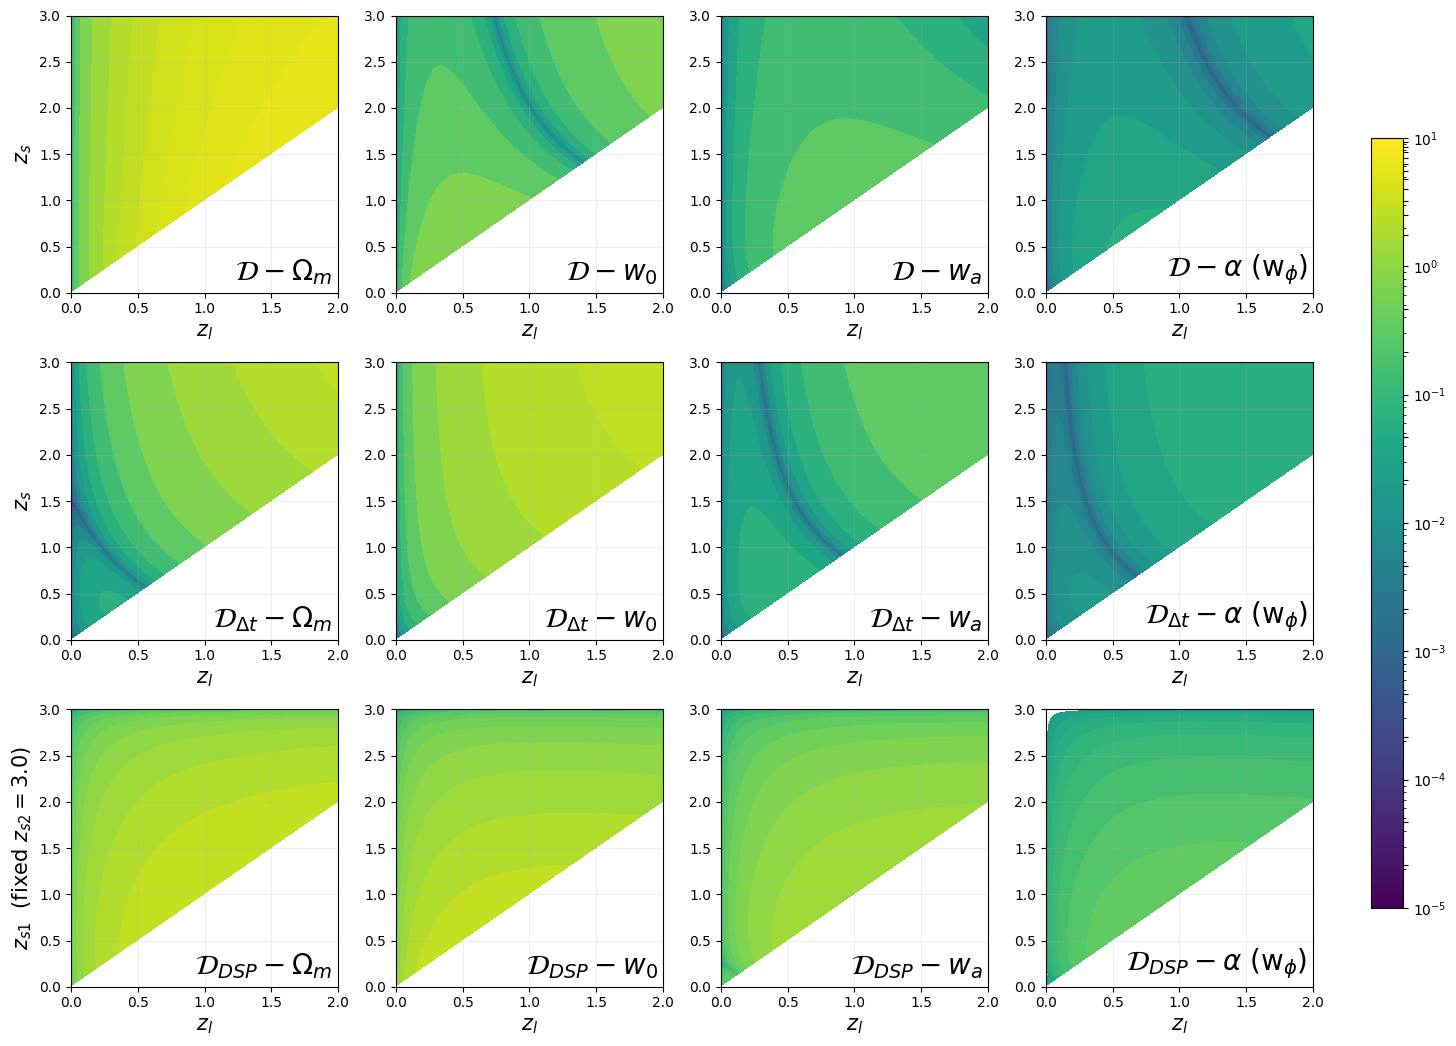

[check] d ln R / d alpha @ (zl=1.00, zs=1.50) = -5.104e-04


In [29]:
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-0.95, wa=0.0)

# Optional: customize per-subplot lower limits (vmin) if desired
vmins = {
    "R":   {"omega_m": 1.5,   "w0": 1e-3, "wa": 1e-5, "alpha":1e-5},
    "Ddt": {"omega_m": 1e-3,  "w0": 0.1, "wa": 1e-5, "alpha":1e-5},
    "beta":{"omega_m": 0.02,  "w0": 1e-3, "wa": 1e-5, "alpha":1e-5},  # example tweak
}

plot_sensitivity_contours_3x4(
    cosmo_cpl,
    zl_min=0.0, zl_max=2.0, zl_step=0.01,
    zs_min=0.0, zs_max=3.0, zs_step=0.01,
    zs2_fixed=3., zs1_step=0.01,
    sigma_frac=0.1,
    outputname="contours_all_3x4.png",
    wphi_alpha=1.45
    
)
